# Payload Episode Evaluation Analysis

This notebook analyzes episode-based quadruped locomotion evaluation CSVs collected under static payload sweeps. It processes one file at a time to avoid keeping all raw logs in memory, computes the existing scalar metrics, collects per-episode success/failure results, and creates payload-vs-performance plots.


In [1]:
import os, re, gc, ast
from pathlib import Path
from typing import Optional, Sequence, Tuple, List
from concurrent.futures import ProcessPoolExecutor, as_completed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

try:
    import seaborn as sns
except ImportError:
    sns = None


## Configuration


In [2]:
EXP_FOLDER = Path("exp_data_corl_10/payload_max")
RESULTS_DIR = EXP_FOLDER / "payload_analysis_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Update these to match your filename prefixes.
APPROACHES = ["go1_pact", "go1_pos", "go1_tau", "go1_abl1", "go1_abl2", "go1_abl3", "go1_rl2ac"]
# APPROACHES = ["go1_tau"]
TERRAINS = ["plane", "rough", "slope", "stairs", "discrete", "wave"]
TERRAIN_FILTER = ["plane"]          # e.g., ["plane"] or None
DISTURBANCE_PREFIX = "payload"
PAYLOAD_ORDER = None           # e.g., [0, 2, 4, 6, 8, 10, 12]
SUCCESS_THRESHOLD = 0.80
HIGHLIGHT_APPROACH = "PC"
RECOMPUTE_METRICS = True
APPROACH_ORDER = ['DW', 'TO', 'AB1', 'AB2', 'AB3', 'PC', "RA"]
# APPROACH_ORDER = ['TO']

BASE_HEIGHT_TARGET = 0.30
EPS = 1e-8

JOINT_LIMITS = np.array([
    [-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
    [ 1.047,  2.966, -0.837,  1.047,  2.966, -0.837,  1.047,  2.966, -0.837,  1.047,  2.966, -0.837],
])
JOINT_TORQUE_LIMITS = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

ARRAY_COLUMNS = [
    "base_cmd", "base_pose", "base_rpy", "dof_pose", "base_lin_vel", "base_ang_vel",
    "dof_vel", "proj_grav", "feet_pos", "tau_act", "grf", "q_des", "tau_ff", "tau_pd",
    "payload", "com_shift", "rand_push", "rand_wrench",
]
USECOLS = None  # set to a list of columns to reduce memory even further

def _display_approach_name(approach):
    mapping = {"go1_pact": "PC", "go1_tau": "TO", "go1_pos": "DW", "go1_abl1": "AB1", "go1_abl2": "AB2", "go1_abl3": "AB3", "go1_rl2ac":"RA"}
    return mapping.get(approach, approach)


FIGURE_SIZE = (8.0, 2.6)
SAVE_AS_PDF = True

## Loading and filename parsing


In [3]:
def string_to_array(value):
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return value
    return value


def get_csv_converters(columns=ARRAY_COLUMNS):
    return {c: string_to_array for c in columns}


def _decode_bound_token(token: str) -> Optional[float]:
    token = token.replace("neg", "-").replace("p", ".")
    try:
        return float(token)
    except Exception:
        return None


def parse_payload_from_disturbance(disturbance_condition: str) -> Optional[float]:
    """Parse payload mass from tags like payload_4_4_episodes or payload_neg3_12_episodes."""
    if not isinstance(disturbance_condition, str) or "payload" not in disturbance_condition:
        return None
    tokens = disturbance_condition.split("_")
    try:
        i = tokens.index("payload")
    except ValueError:
        return None
    vals = []
    for tok in tokens[i+1:]:
        if tok in {"episodes", "com", "none", "push"}:
            break
        val = _decode_bound_token(tok)
        if val is None:
            break
        vals.append(val)
        if len(vals) >= 2:
            break
    if not vals:
        return None
    return max(vals) if len(vals) >= 2 else vals[0]


def parse_eval_filename(path: Path, approaches: Sequence[str], terrains: Sequence[str]) -> Optional[dict]:
    stem = Path(path).stem
    for approach in sorted(approaches, key=len, reverse=True):
        prefix = f"{approach}_"
        if not stem.startswith(prefix):
            continue
        remainder = stem[len(prefix):]
        parts = remainder.split("_")        
        if len(parts) < 2:
            continue
        terrain = parts[0]
        
        if terrain not in terrains:
            continue
        disturbance_condition = "_".join(parts[1:])
        
        return dict(
            approach=approach,
            terrain=terrain,
            disturbance_condition=disturbance_condition,
            payload_mass_from_name=parse_payload_from_disturbance(disturbance_condition),
            path=Path(path),
        )
    return None


def find_eval_files(exp_folder, approaches, terrains, terrain_filter=None, disturbance_prefix="payload"):
    exp_folder = Path(exp_folder)
    terrain_filter = set(terrain_filter) if terrain_filter is not None else None
    records = []
    for path in sorted(exp_folder.rglob("*.csv")):
        # print(path)
        if "analysis_results" in path.parts or "payload_analysis_results" in path.parts:
            continue
        info = parse_eval_filename(path, approaches, terrains)
        if info is None:
            continue
        if terrain_filter is not None and info["terrain"] not in terrain_filter:
            continue
        if disturbance_prefix is not None and not info["disturbance_condition"].startswith(disturbance_prefix):
            continue
        records.append(info)
    out = pd.DataFrame(records)
    if len(out):
        out = out.sort_values(["approach", "terrain", "payload_mass_from_name", "path"], na_position="last")
    return out


def load_eval_csv(path: Path, usecols=USECOLS):
    converters = get_csv_converters()
    if usecols is not None:
        converters = {k:v for k,v in converters.items() if k in usecols}
    return pd.read_csv(path, converters=converters, usecols=usecols)


In [4]:
file_table = find_eval_files(
    EXP_FOLDER, APPROACHES, TERRAINS,
    terrain_filter=TERRAIN_FILTER,
    disturbance_prefix=DISTURBANCE_PREFIX,
)
print(f"Found {len(file_table)} files")
file_table


Found 119 files


,approach,terrain,disturbance_condition,payload_mass_from_name,path
11,go1_abl1,plane,payload_4_4_episodes,4.0,exp_data_corl_10/payload_max/go1_abl1_plane_pa...
12,go1_abl1,plane,payload_5_5_episodes,5.0,exp_data_corl_10/payload_max/go1_abl1_plane_pa...
13,go1_abl1,plane,payload_6_6_episodes,6.0,exp_data_corl_10/payload_max/go1_abl1_plane_pa...
14,go1_abl1,plane,payload_7_7_episodes,7.0,exp_data_corl_10/payload_max/go1_abl1_plane_pa...
15,go1_abl1,plane,payload_8_8_episodes,8.0,exp_data_corl_10/payload_max/go1_abl1_plane_pa...
...,...,...,...,...,...
108,go1_tau,plane,payload_16_16_episodes,16.0,exp_data_corl_10/payload_max/go1_tau_plane_pay...
109,go1_tau,plane,payload_17_17_episodes,17.0,exp_data_corl_10/payload_max/go1_tau_plane_pay...
110,go1_tau,plane,payload_18_18_episodes,18.0,exp_data_corl_10/payload_max/go1_tau_plane_pay...
111,go1_tau,plane,payload_19_19_episodes,19.0,exp_data_corl_10/payload_max/go1_tau_plane_pay...


## Existing metric utilities


In [5]:
def as_array(df, column, valid_mask=None):
    if column not in df.columns:
        return None
    s = df[column]
    if valid_mask is not None:
        s = s.loc[valid_mask]
    if len(s) == 0:
        return None
    try:
        return np.asarray(s.to_list())
    except Exception:
        return None


def safe_mean(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanmean(x))

def safe_std(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanstd(x))

def rmse(x):
    return float(np.sqrt(np.nanmean(np.square(np.asarray(x)))))

def mae(x):
    return float(np.nanmean(np.abs(np.asarray(x))))

def mean_norm(x, axis=1, ord=1):
    return float(np.nanmean(np.linalg.norm(np.asarray(x), axis=axis, ord=ord)))

def std_norm(x, axis=1, ord=1):
    return float(np.nanstd(np.linalg.norm(np.asarray(x), axis=axis, ord=ord)))


def scalar_payload_from_column(df):
    if "payload" not in df.columns or len(df) == 0:
        return None
    vals = []
    for v in df["payload"].dropna().head(500):
        arr = np.asarray(v, dtype=float).reshape(-1)
        vals.extend(arr.tolist())
    return float(np.nanmedian(vals)) if vals else None


def get_row_mask_for_metrics(df):
    if "valid_episode" in df.columns:
        return df["valid_episode"].astype(float).to_numpy() == 1
    return np.ones(len(df), dtype=bool)


In [6]:
def compute_eval_metrics(
    df,
    approach="pact",
    base_height_target=0.30,
    joint_limits=None,
    joint_torque_limits=None,
    pact_metric_approaches=("pact", "abl"),
    eps=1e-8,
):
    """Compute scalar metrics from the original notebook; failure rows are excluded from continuous metrics."""
    metrics = {}
    use_pact_metrics = approach is not None and any(k.lower() in approach.lower() for k in pact_metric_approaches)

    n_total = len(df)
    if "failure_reset" in df.columns:
        failure = df["failure_reset"].astype(float).to_numpy()
    elif "failure" in df.columns:
        failure = df["failure"].astype(float).to_numpy()
    else:
        failure = np.zeros(n_total)
    valid_mask = failure == 0

    metrics["num_rows_total"] = int(n_total)
    metrics["num_rows_valid"] = int(valid_mask.sum())
    metrics["num_failures"] = int(failure.sum())
    metrics["failure_rate_rowwise"] = float(failure.mean()) if n_total else np.nan
    if valid_mask.sum() == 0:
        return metrics

    q_actions = as_array(df, "q_des", valid_mask)
    q_obs = as_array(df, "dof_pose", valid_mask)
    vel_cmds = as_array(df, "base_cmd", valid_mask)
    lin_vel = as_array(df, "base_lin_vel", valid_mask)
    ang_vel = as_array(df, "base_ang_vel", valid_mask)
    base_pose = as_array(df, "base_pose", valid_mask)
    proj_grav = as_array(df, "proj_grav", valid_mask)
    q_vel = as_array(df, "dof_vel", valid_mask)
    q_tau = as_array(df, "tau_act", valid_mask)
    grfs = as_array(df, "grf", valid_mask)
    ff_tau = as_array(df, "tau_ff", valid_mask)
    pd_tau = as_array(df, "tau_pd", valid_mask)

    if q_actions is not None and q_obs is not None and q_actions.shape == q_obs.shape:
        e = q_actions - q_obs
        metrics["dof_tracking_rmse"] = rmse(e)
        metrics["dof_tracking_mae"] = mae(e)
        metrics["q_action_norm_mean"] = mean_norm(q_actions)
        metrics["q_action_norm_std"] = std_norm(q_actions)
        if joint_limits is not None:
            jl = np.asarray(joint_limits)
            err = -(q_actions - jl[0, :]).clip(max=0.0)
            err += (q_actions - jl[1, :]).clip(min=0.0)
            metrics["joint_limit_violation_mean"] = float(np.mean(err))

    if vel_cmds is not None and lin_vel is not None and ang_vel is not None:
        lin_err = vel_cmds[:, 0:2] - lin_vel[:, 0:2]
        ang_err = vel_cmds[:, 2] - ang_vel[:, 2]
        cmd_err = np.concatenate((lin_err, ang_err[:, None]), axis=1)
        metrics["lin_cmd_rmse"] = rmse(lin_err)
        metrics["lin_cmd_mae"] = mae(lin_err)
        metrics["lin_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(lin_err))))
        metrics["ang_cmd_rmse"] = rmse(ang_err)
        metrics["ang_cmd_mae"] = mae(ang_err)
        metrics["ang_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(ang_err))))
        metrics["total_cmd_rmse"] = rmse(cmd_err)
        metrics["total_cmd_mae"] = mae(cmd_err)

    if base_pose is not None:
        h = base_height_target - base_pose[:, 2]
        metrics["height_rmse"] = rmse(h)
        metrics["height_mae"] = mae(h)

    if proj_grav is not None:
        orn = np.linalg.norm(proj_grav[:, 0:2], axis=1, ord=1)
        metrics["projected_gravity_rp_norm_mean"] = safe_mean(orn)
        metrics["projected_gravity_rp_norm_std"] = safe_std(orn)

    if lin_vel is not None and ang_vel is not None:
        z_vel = lin_vel[:, 2]
        av_rp = np.linalg.norm(ang_vel[:, 0:2], axis=1, ord=1)
        unwanted = np.concatenate((z_vel[:, None], ang_vel[:, 0:2]), axis=1)
        unwanted_norm = np.linalg.norm(unwanted, axis=1, ord=1)
        metrics["z_vel_rmse"] = rmse(z_vel)
        metrics["z_vel_mae"] = mae(z_vel)
        metrics["ang_vel_rp_norm_mean"] = safe_mean(av_rp)
        metrics["ang_vel_rp_norm_std"] = safe_std(av_rp)
        metrics["total_unwanted_vel_norm_mean"] = safe_mean(unwanted_norm)
        metrics["total_unwanted_vel_norm_std"] = safe_std(unwanted_norm)

    if q_vel is not None and q_tau is not None and q_vel.shape == q_tau.shape:
        power = q_vel * q_tau
        metrics["joint_power_norm_mean"] = mean_norm(power)
        metrics["joint_power_norm_std"] = std_norm(power)

    if grfs is not None:
        flat = grfs.reshape(grfs.shape[0], -1)
        metrics["grf_norm_mean"] = mean_norm(flat)
        metrics["grf_norm_std"] = std_norm(flat)
    if ff_tau is not None:
        metrics["ff_tau_norm_mean"] = mean_norm(ff_tau)
        metrics["ff_tau_norm_std"] = std_norm(ff_tau)
    if pd_tau is not None:
        metrics["pd_tau_norm_mean"] = mean_norm(pd_tau)
        metrics["pd_tau_norm_std"] = std_norm(pd_tau)

    if use_pact_metrics and ff_tau is not None and pd_tau is not None:
        total_tau = ff_tau + pd_tau
        metrics["total_tau_cmd_norm_mean"] = mean_norm(total_tau)
        metrics["total_tau_cmd_norm_std"] = std_norm(total_tau)
        ff_norm = np.linalg.norm(ff_tau, axis=1)
        pd_norm = np.linalg.norm(pd_tau, axis=1)
        metrics["ff_tau_ratio_mean"] = safe_mean(ff_norm / (ff_norm + pd_norm + eps))
        metrics["pd_tau_ratio_mean"] = safe_mean(pd_norm / (ff_norm + pd_norm + eps))
        metrics["pd_to_ff_tau_norm_ratio"] = float(np.mean(pd_norm) / (np.mean(ff_norm) + eps))
        if joint_torque_limits is not None:
            lim = np.asarray(joint_torque_limits)
            violation = -(total_tau - (-lim)).clip(max=0.0)
            violation += (total_tau - lim).clip(min=0.0)
            metrics["joint_torque_limit_violation_mean"] = float(np.mean(violation))

    if use_pact_metrics and ff_tau is not None and pd_tau is not None and q_vel is not None:
        ff_power = ff_tau * q_vel
        pd_power = pd_tau * q_vel
        total_power = (ff_tau + pd_tau) * q_vel
        dot = np.sum(ff_power * pd_power, axis=1)
        ffn = np.linalg.norm(ff_power, axis=1)
        pdn = np.linalg.norm(pd_power, axis=1)
        cos = dot / ((ffn * pdn) + eps)
        metrics["ff_power_norm_mean"] = safe_mean(ffn)
        metrics["pd_power_norm_mean"] = safe_mean(pdn)
        metrics["pd_to_ff_power_ratio"] = float(np.mean(pdn) / (np.mean(ffn) + eps))
        metrics["power_alignment_mean"] = safe_mean(cos)
        metrics["power_alignment_std"] = safe_std(cos)
        metrics["fraction_antagonistic_energy"] = float(np.sum(np.maximum(-dot, 0.0)) / (np.sum(np.abs(dot)) + eps))
        numerator = np.abs(ff_power) + np.abs(pd_power) - np.abs(total_power)
        denominator = np.abs(ff_power) + np.abs(pd_power)
        metrics["internal_power_cancellation"] = float(np.mean(numerator) / (np.mean(denominator) + eps))
    return metrics


## Per-episode aggregation and memory-efficient processing


In [7]:
def _failure_series(df):
    if "failure_reset" in df.columns:
        return df["failure_reset"].astype(float)
    if "failure" in df.columns:
        return df["failure"].astype(float)
    return pd.Series(np.zeros(len(df)), index=df.index)


def _timeout_series(df):
    if "time_out" in df.columns:
        return df["time_out"].astype(float)
    return pd.Series(np.zeros(len(df)), index=df.index)


def compute_episode_results(df, approach, terrain, disturbance_condition, payload_mass, source_file):
    if "episode" not in df.columns:
        df = df.copy()
        df["episode"] = 0
    tmp = df.copy()
    tmp["_failure_event"] = _failure_series(tmp)
    tmp["_timeout_event"] = _timeout_series(tmp)

    q_des = as_array(tmp, "q_des")
    q = as_array(tmp, "dof_pose")
    if q_des is not None and q is not None and q_des.shape == q.shape:
        tmp["_dof_tracking_mae_row"] = np.mean(np.abs(q_des - q), axis=1)

    pose = as_array(tmp, "base_pose")
    if pose is not None and pose.ndim == 2 and pose.shape[1] >= 3:
        tmp["_height_abs_error_row"] = np.abs(BASE_HEIGHT_TARGET - pose[:, 2])

    agg = {"_failure_event": "max", "_timeout_event": "max"}
    if "episode_step" in tmp.columns:
        agg["episode_step"] = "max"
    if "_dof_tracking_mae_row" in tmp.columns:
        agg["_dof_tracking_mae_row"] = "mean"
    if "_height_abs_error_row" in tmp.columns:
        agg["_height_abs_error_row"] = "mean"

    ep = tmp.groupby("episode", as_index=False).agg(agg).rename(columns={
        "_failure_event": "failure",
        "_timeout_event": "time_out",
        "episode_step": "episode_length",
        "_dof_tracking_mae_row": "dof_tracking_mae",
        "_height_abs_error_row": "height_mae",
    })
    ep["success"] = 1.0 - ep["failure"].astype(float)
    ep["approach"] = approach
    ep["terrain"] = terrain
    ep["disturbance_condition"] = disturbance_condition
    ep["payload_mass"] = payload_mass
    ep["source_file"] = source_file
    cols = ["approach", "terrain", "payload_mass", "disturbance_condition", "source_file", "episode", "success", "failure", "time_out", "episode_length", "dof_tracking_mae", "height_mae"]
    return ep[[c for c in cols if c in ep.columns]]


def process_one_file(row):
    path = Path(row["path"])
    approach, terrain = row["approach"], row["terrain"]
    disturbance_condition = row["disturbance_condition"]

    df = load_eval_csv(path)
    df = df.loc[get_row_mask_for_metrics(df)].reset_index(drop=True)

    payload_mass = row.get("payload_mass_from_name", np.nan)
    if pd.isna(payload_mass):
        payload_mass = scalar_payload_from_column(df)
    if payload_mass is None:
        payload_mass = np.nan

    metrics = compute_eval_metrics(
        df,
        approach=approach,
        base_height_target=BASE_HEIGHT_TARGET,
        joint_limits=JOINT_LIMITS,
        joint_torque_limits=JOINT_TORQUE_LIMITS,
        eps=EPS,
    )
    ep = compute_episode_results(df, approach, terrain, disturbance_condition, payload_mass, str(path))
    metrics.update({
        "approach": approach,
        "terrain": terrain,
        "disturbance_condition": disturbance_condition,
        "payload_mass": payload_mass,
        "source_file": str(path),
        "num_episodes": int(len(ep)),
        "episode_failure_rate": float(ep["failure"].mean()) if len(ep) else np.nan,
        "episode_success_rate": float(ep["success"].mean()) if len(ep) else np.nan,
    })
    del df
    gc.collect()
    return metrics, ep


def run_payload_analysis(file_table, results_dir=RESULTS_DIR):
    file_metrics_path = results_dir / "per_file_metrics.csv"
    episode_results_path = results_dir / "per_episode_results.csv"
    if (not RECOMPUTE_METRICS) and file_metrics_path.exists() and episode_results_path.exists():
        return pd.read_csv(file_metrics_path), pd.read_csv(episode_results_path)

    metric_rows, episode_chunks = [], []
    for i, row in file_table.reset_index(drop=True).iterrows():
        print(f"[{i+1}/{len(file_table)}] {row['path']}")
        m, ep = process_one_file(row)
        metric_rows.append(m)
        episode_chunks.append(ep)
        pd.DataFrame(metric_rows).to_csv(file_metrics_path, index=False)
        pd.concat(episode_chunks, ignore_index=True).to_csv(episode_results_path, index=False)

    per_file = pd.DataFrame(metric_rows)
    per_ep = pd.concat(episode_chunks, ignore_index=True) if episode_chunks else pd.DataFrame()
    per_file.to_csv(file_metrics_path, index=False)
    per_ep.to_csv(episode_results_path, index=False)
    return per_file, per_ep


def _process_one_file_from_dict(row_dict):
    """
    Helper for multiprocessing.

    We pass a plain dict instead of a pandas Series because dicts are easier
    and safer to pickle across processes.
    """
    row = pd.Series(row_dict)
    m, ep = process_one_file(row)
    return m, ep


def run_payload_analysis_parallel(
    file_table,
    results_dir=RESULTS_DIR,
    max_workers=None,
    save_every=5,
):
    file_metrics_path = results_dir / "per_file_metrics.csv"
    episode_results_path = results_dir / "per_episode_results.csv"

    if (
        (not RECOMPUTE_METRICS)
        and file_metrics_path.exists()
        and episode_results_path.exists()
    ):
        return pd.read_csv(file_metrics_path), pd.read_csv(episode_results_path)

    results_dir.mkdir(parents=True, exist_ok=True)

    if max_workers is None:
        max_workers = max(1, min(os.cpu_count() or 1, len(file_table)))

    rows = file_table.reset_index(drop=True).to_dict(orient="records")

    metric_rows = []
    episode_chunks = []

    completed = 0
    total = len(rows)

    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(_process_one_file_from_dict, row): row
            for row in rows
        }

        for future in as_completed(futures):
            row = futures[future]
            completed += 1

            try:
                m, ep = future.result()
            except Exception as e:
                print(f"[{completed}/{total}] FAILED: {row.get('path')}")
                print(e)
                continue

            print(f"[{completed}/{total}] finished: {row.get('path')}")

            metric_rows.append(m)

            if ep is not None and len(ep) > 0:
                episode_chunks.append(ep)

            if completed % save_every == 0:
                pd.DataFrame(metric_rows).to_csv(file_metrics_path, index=False)

                if episode_chunks:
                    pd.concat(episode_chunks, ignore_index=True).to_csv(
                        episode_results_path,
                        index=False,
                    )

    per_file = pd.DataFrame(metric_rows)
    per_ep = (
        pd.concat(episode_chunks, ignore_index=True)
        if episode_chunks
        else pd.DataFrame()
    )

    per_file.to_csv(file_metrics_path, index=False)
    per_ep.to_csv(episode_results_path, index=False)

    return per_file, per_ep


In [8]:
# per_file_metrics, per_episode_results = run_payload_analysis(file_table, RESULTS_DIR)
# print(f"Per-file rows: {len(per_file_metrics)}")
# print(f"Per-episode rows: {len(per_episode_results)}")
# per_file_metrics.head()

per_file_metrics, per_episode_results = run_payload_analysis_parallel(
    file_table,
    max_workers=20,
    save_every=5,
)
print(f"Per-file rows: {len(per_file_metrics)}")
print(f"Per-episode rows: {len(per_episode_results)}")
per_file_metrics.columns

[1/119] finished: exp_data_corl_10/payload_max/go1_abl1_plane_payload_14_14_episodes.csv
[2/119] finished: exp_data_corl_10/payload_max/go1_abl2_plane_payload_5_5_episodes.csv
[3/119] finished: exp_data_corl_10/payload_max/go1_abl1_plane_payload_20_20_episodes.csv
[4/119] finished: exp_data_corl_10/payload_max/go1_abl1_plane_payload_16_16_episodes.csv
[5/119] finished: exp_data_corl_10/payload_max/go1_abl1_plane_payload_8_8_episodes.csv
[6/119] finished: exp_data_corl_10/payload_max/go1_abl1_plane_payload_11_11_episodes.csv
[7/119] finished: exp_data_corl_10/payload_max/go1_abl1_plane_payload_6_6_episodes.csv
[8/119] finished: exp_data_corl_10/payload_max/go1_abl1_plane_payload_10_10_episodes.csv
[9/119] finished: exp_data_corl_10/payload_max/go1_abl1_plane_payload_7_7_episodes.csv
[10/119] finished: exp_data_corl_10/payload_max/go1_abl1_plane_payload_4_4_episodes.csv
[11/119] finished: exp_data_corl_10/payload_max/go1_abl1_plane_payload_17_17_episodes.csv
[12/119] finished: exp_data_c

Index(['num_rows_total', 'num_rows_valid', 'num_failures',
       'failure_rate_rowwise', 'dof_tracking_rmse', 'dof_tracking_mae',
       'q_action_norm_mean', 'q_action_norm_std', 'joint_limit_violation_mean',
       'lin_cmd_rmse', 'lin_cmd_mae', 'lin_cmd_std_sqroot', 'ang_cmd_rmse',
       'ang_cmd_mae', 'ang_cmd_std_sqroot', 'total_cmd_rmse', 'total_cmd_mae',
       'height_rmse', 'height_mae', 'projected_gravity_rp_norm_mean',
       'projected_gravity_rp_norm_std', 'z_vel_rmse', 'z_vel_mae',
       'ang_vel_rp_norm_mean', 'ang_vel_rp_norm_std',
       'total_unwanted_vel_norm_mean', 'total_unwanted_vel_norm_std',
       'joint_power_norm_mean', 'joint_power_norm_std', 'grf_norm_mean',
       'grf_norm_std', 'ff_tau_norm_mean', 'ff_tau_norm_std',
       'pd_tau_norm_mean', 'pd_tau_norm_std', 'total_tau_cmd_norm_mean',
       'total_tau_cmd_norm_std', 'ff_tau_ratio_mean', 'pd_tau_ratio_mean',
       'pd_to_ff_tau_norm_ratio', 'joint_torque_limit_violation_mean',
       'ff_power_no

## Payload summary tables


In [9]:
def summarize_payload_results(per_episode_results, per_file_metrics):
    ep = per_episode_results.copy()
    agg = dict(
        num_episodes=("episode", "count"),
        success_rate=("success", "mean"),
        failure_rate=("failure", "mean"),
        timeout_rate=("time_out", "mean"),
    )
    if "episode_length" in ep.columns:
        agg["episode_length_mean"] = ("episode_length", "mean")
    if "dof_tracking_mae" in ep.columns:
        agg["dof_tracking_mae"] = ("dof_tracking_mae", "mean")
    if "height_mae" in ep.columns:
        agg["height_mae"] = ("height_mae", "mean")

    summary = ep.groupby(["approach", "terrain", "payload_mass"], as_index=False).agg(**agg)

    metric_cols = [
        "lin_cmd_mae", "ang_cmd_mae", "total_cmd_mae", "total_cmd_rmse",
        "projected_gravity_rp_norm_mean", "z_vel_mae", "ang_vel_rp_norm_mean",
        "joint_power_norm_mean", "grf_norm_mean", "ff_tau_norm_mean", "pd_tau_norm_mean", "total_unwanted_vel_norm_mean"
        "ff_tau_ratio_mean", "pd_to_ff_power_ratio", "power_alignment_mean",
        "fraction_antagonistic_energy", "internal_power_cancellation",
    ]
    metric_cols = [c for c in metric_cols if c in per_file_metrics.columns]
    if metric_cols:
        file_summary = per_file_metrics.groupby(["approach", "terrain", "payload_mass"], as_index=False)[metric_cols].mean()
        summary = summary.merge(file_summary, on=["approach", "terrain", "payload_mass"], how="left")
    return summary.sort_values(["approach", "terrain", "payload_mass"])

payload_summary = summarize_payload_results(per_episode_results, per_file_metrics)
payload_summary.to_csv(RESULTS_DIR / "payload_summary.csv", index=False)
payload_summary.columns


Index(['approach', 'terrain', 'payload_mass', 'num_episodes', 'success_rate',
       'failure_rate', 'timeout_rate', 'episode_length_mean',
       'dof_tracking_mae', 'height_mae', 'lin_cmd_mae', 'ang_cmd_mae',
       'total_cmd_mae', 'total_cmd_rmse', 'projected_gravity_rp_norm_mean',
       'z_vel_mae', 'ang_vel_rp_norm_mean', 'joint_power_norm_mean',
       'grf_norm_mean', 'ff_tau_norm_mean', 'pd_tau_norm_mean',
       'pd_to_ff_power_ratio', 'power_alignment_mean',
       'fraction_antagonistic_energy', 'internal_power_cancellation'],
      dtype='object')

In [10]:
def summarize_payload_results_by_approach(payload_summary):
    metric_cols = [
        c for c in payload_summary.columns
        if c not in ["approach", "terrain", "payload_mass"]
    ]

    approach_summary = (
        payload_summary
        .groupby("approach", as_index=False)[metric_cols]
        .mean()
        .sort_values("approach", ignore_index=True)
    )

    return approach_summary


payload_approach_summary = summarize_payload_results_by_approach(payload_summary)
# payload_approach_summary.to_csv(
#     RESULTS_DIR / "payload_approach_summary.csv",
#     index=False,
# )

payload_approach_summary.round(4)

payload_summary.approach.unique()

array(['go1_abl1', 'go1_abl2', 'go1_abl3', 'go1_pact', 'go1_pos',
       'go1_rl2ac', 'go1_tau'], dtype=object)

In [11]:
compact_cols = [
    "approach", "terrain", "payload_mass", "num_episodes", "success_rate", "failure_rate",
    "dof_tracking_mae", "height_mae", "total_cmd_mae", "projected_gravity_rp_norm_mean", "ang_vel_rp_norm_mean", "z_vel_mae",
    "total_unwanted_vel_norm_mean", "power_alignment_mean", "joint_power_norm_mean", "internal_power_cancellation",
]
compact_cols = [c for c in compact_cols if c in payload_approach_summary.columns]
payload_approach_summary[compact_cols].round(4)


,approach,num_episodes,success_rate,failure_rate,dof_tracking_mae,height_mae,total_cmd_mae,projected_gravity_rp_norm_mean,ang_vel_rp_norm_mean,z_vel_mae,power_alignment_mean,joint_power_norm_mean,internal_power_cancellation
0,go1_abl1,100.0,0.9606,0.0394,0.1333,0.0356,0.1384,0.0678,0.6875,0.0696,-0.3583,39.1265,0.4097
1,go1_abl2,100.0,0.8718,0.1282,0.1503,0.0535,0.1610,0.0787,0.7236,0.0753,0.8371,37.8779,0.0290
2,go1_abl3,100.0,0.8629,0.1371,0.1581,0.0675,0.2004,0.0849,0.7574,0.0838,0.8419,40.5539,0.0333
3,go1_pact,100.0,0.9465,0.0535,0.1399,0.0495,0.1634,0.0717,0.6580,0.0653,0.8339,34.0048,0.0321
4,go1_pos,100.0,0.8153,0.1847,0.2668,0.0431,0.1740,0.0903,0.8854,0.0934,NaN,57.7480,NaN
5,go1_rl2ac,100.0,0.9276,0.0724,0.1824,0.0367,0.1598,0.0740,0.6778,0.0690,NaN,89.4867,NaN
6,go1_tau,100.0,0.7912,0.2088,0.5282,0.0865,0.1873,0.1035,0.7605,0.0767,NaN,44.5385,NaN


In [12]:
compact_cols = [
    "approach", "terrain", "payload_mass", "num_episodes", "success_rate", "failure_rate",
    "dof_tracking_mae", "height_mae", "total_cmd_mae", "projected_gravity_rp_norm_mean",
    "joint_power_norm_mean", "internal_power_cancellation",
]
compact_cols = [c for c in compact_cols if c in payload_summary.columns]
payload_summary[compact_cols].round(4)


,approach,terrain,payload_mass,num_episodes,success_rate,failure_rate,dof_tracking_mae,height_mae,total_cmd_mae,projected_gravity_rp_norm_mean,joint_power_norm_mean,internal_power_cancellation
0,go1_abl1,plane,4.0,100,1.00,0.00,0.0862,0.0353,0.1075,0.0527,35.3590,0.4822
1,go1_abl1,plane,5.0,100,1.00,0.00,0.0885,0.0308,0.1091,0.0525,35.5554,0.4712
2,go1_abl1,plane,6.0,100,1.00,0.00,0.0913,0.0260,0.1119,0.0525,35.6923,0.4599
3,go1_abl1,plane,7.0,100,1.00,0.00,0.0950,0.0210,0.1148,0.0521,35.9351,0.4491
4,go1_abl1,plane,8.0,100,1.00,0.00,0.0995,0.0161,0.1180,0.0531,36.3480,0.4386
...,...,...,...,...,...,...,...,...,...,...,...,...
114,go1_tau,plane,16.0,100,0.62,0.38,0.6024,0.1148,0.2253,0.1223,42.0373,NaN
115,go1_tau,plane,17.0,100,0.60,0.40,0.6108,0.1179,0.2327,0.1236,42.2575,NaN
116,go1_tau,plane,18.0,100,0.52,0.48,0.6235,0.1231,0.2360,0.1354,39.9825,NaN
117,go1_tau,plane,19.0,100,0.37,0.63,0.6279,0.1265,0.2544,0.1474,39.3810,NaN


In [13]:
payload_summary.approach.unique()

array(['go1_abl1', 'go1_abl2', 'go1_abl3', 'go1_pact', 'go1_pos',
       'go1_rl2ac', 'go1_tau'], dtype=object)

## Plotting helpers


In [14]:
def prepare_plot_summary(summary, terrain=None):
    out = summary.copy()
    out["approach_label"] = out["approach"].map(_display_approach_name)
    if terrain is not None:
        out = out[out["terrain"] == terrain]
    return out.sort_values(["approach_label", "payload_mass"])

def save_paper_fig(fig, path, pad_inches=0.00):
    fig.savefig(
        path,
        bbox_inches="tight",
        pad_inches=pad_inches,
        dpi=300,
    )

def compactify_plot(
    fig,
    ax=None,
    pad=0.00,
    tick_pad=0,
    label_pad=0,
    title_pad=0,
):
    """
    Reduce whitespace around a matplotlib figure for paper-ready plots.
    """
    axes = fig.axes if ax is None else [ax]

    for a in axes:
        a.tick_params(axis="both", which="major", pad=tick_pad)
        a.xaxis.labelpad = label_pad
        a.yaxis.labelpad = label_pad

    fig.tight_layout(pad=pad)
    return fig

def payload_curve_dict(summary, value_col, terrain=None):
    plot_df = prepare_plot_summary(summary, terrain=terrain)
    payloads = PAYLOAD_ORDER
    if payloads is None:
        payloads = sorted(plot_df["payload_mass"].dropna().unique())
    payloads = np.asarray(payloads, dtype=float)
    curves = {}
    for approach, group in plot_df.groupby("approach_label"):
        s = group.groupby("payload_mass")[value_col].mean()
        curves[approach] = np.asarray([s.get(p, np.nan) for p in payloads], dtype=float)
    return payloads, curves

def plot_payload_success_curves(
    payloads,
    success_rates,
    approach_order=None,
    highlight="PACT",
    ax=None,
    shade_until=None,
    shade_label=None,
    shade_alpha=0.18,
):
    if ax is None:
        fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    else:
        fig = ax.figure

    payloads = np.asarray(payloads)

    # Grey out background from the left edge up to shade_until.
    if shade_until is not None:
        x_min = np.nanmin(payloads)
        ax.axvspan(
            x_min,
            shade_until,
            color="gray",
            alpha=shade_alpha,
            zorder=0,
            label=shade_label,
        )

    if approach_order is None:
        approach_order = list(success_rates.keys())

    markers = ["o", "s", "^", "D", "v", "P", "X", "*"]

    for i, approach in enumerate(approach_order):
        y = np.asarray(success_rates[approach])
        is_highlight = approach == highlight

        ax.plot(
            payloads,
            100.0 * y,
            marker=markers[i % len(markers)],
            linewidth=2.6 if is_highlight else 1.2,
            markersize=5.5 if is_highlight else 4.0,
            alpha=1.0 if is_highlight else 0.55,
            label=approach,
            zorder=10 if is_highlight else 2,
        )

    ax.set_xlabel("Payload (kg)", fontsize=16)
    # ax.set_ylabel("Success Rate (%)")
    ax.set_ylim(-3, 103)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.grid(True, axis="y", alpha=0.3)

    # ax.legend(
    #     loc="center left",
    #     bbox_to_anchor=(1.02, 0.5),
    #     frameon=False,
    #     fontsize=8,
    # )
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    ax.legend(
        loc="lower left",
        bbox_to_anchor=(0.02, 0.02),
        ncol=4,
        frameon=True,
        fontsize=12,
    )

    fig.tight_layout()
    return fig, ax


def plot_payload_failure_curves(payloads, failure_rates, approach_order=None, highlight="PACT", ax=None, shade_until=None, shade_label=None, shade_alpha=0.18):
    if ax is None:
        fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    else:
        fig = ax.figure
    
    # Grey out background from the left edge up to shade_until.
    if shade_until is not None:
        x_min = np.nanmin(payloads)
        ax.axvspan(
            x_min,
            shade_until,
            color="gray",
            alpha=shade_alpha,
            zorder=0,
            label=shade_label,
        )
    
    
    if approach_order is None:
        approach_order = list(failure_rates.keys())
    markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
    for i, approach in enumerate(approach_order):
        y = np.asarray(failure_rates[approach])
        is_highlight = approach == highlight
        ax.plot(payloads, 100.0*y, marker=markers[i % len(markers)], linewidth=2.6 if is_highlight else 1.2,
                markersize=5.5 if is_highlight else 4.0, alpha=1.0 if is_highlight else 0.55,
                label=approach, zorder=10 if is_highlight else 2)
    ax.set_xlabel("Payload (kg)")
    ax.set_ylabel("Failure Rate (%)")
    ax.set_ylim(-3, 103)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.grid(True, axis="y", alpha=0.3)
    # ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        ncol=4,  # 7 entries -> 2 rows
        frameon=True,
        fontsize=8,
    )
    fig.tight_layout()
    return fig, ax


def compute_payload_threshold(payloads, success_rates, threshold=0.8):
    payloads = np.asarray(payloads)
    thresholds = {}
    for approach, rates in success_rates.items():
        rates = np.asarray(rates)
        valid = payloads[rates >= threshold]
        thresholds[approach] = valid.max() if len(valid) > 0 else 0.0
    return thresholds


# def plot_payload_thresholds(thresholds, threshold=0.8, highlight="PACT", approach_order=None):
#     if approach_order is None:
#         approaches = list(thresholds.keys())
#     else:
#         # Keep only approaches that exist in thresholds.
#         approaches = [a for a in approach_order if a in thresholds]

#         # Optionally append any approaches not specified in approach_order.
#         remaining = [a for a in thresholds.keys() if a not in approaches]
#         approaches.extend(remaining)
        
#     values = [thresholds[a] for a in approaches]
#     fig, ax = plt.subplots(figsize=(6.5, 2.8))
#     bars = ax.bar(approaches, values)
#     for bar, approach in zip(bars, approaches):
#         if approach == highlight:
#             bar.set_linewidth(2.0)
#             bar.set_edgecolor("black")
#     ax.set_ylabel(f"Max Payload (kg) at\n≥{int(100 * threshold)}% Success")
#     ax.set_xlabel("Approach")
#     ax.tick_params(axis="x", rotation=30)
#     ax.grid(True, axis="y", alpha=0.3)
#     fig.tight_layout()
#     return fig, ax

def plot_payload_thresholds(
    thresholds,
    threshold=0.8,
    highlight="PACT",
    approach_order=None,
    annotate=True,
):
    if approach_order is None:
        approaches = list(thresholds.keys())
    else:
        # Keep only approaches that exist in thresholds.
        approaches = [a for a in approach_order if a in thresholds]

        # Optionally append any approaches not specified in approach_order.
        remaining = [a for a in thresholds.keys() if a not in approaches]
        approaches.extend(remaining)

    values = np.asarray([thresholds[a] for a in approaches], dtype=float)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    bars = ax.bar(approaches, values)

    for bar, approach in zip(bars, approaches):
        if approach == highlight:
            bar.set_linewidth(2.0)
            bar.set_edgecolor("black")

    if annotate:
        ax.bar_label(
            bars,
            labels=[f"{v:.1f}" if np.isfinite(v) else "" for v in values],
            padding=2,
            fontsize=8,
        )

        # Add headroom so labels are not clipped.
        ymin, ymax = ax.get_ylim()
        y_range = ymax - ymin
        ax.set_ylim(ymin, ymax + 0.10 * y_range)

    ax.set_ylabel(f"Max Payload (kg) at\n≥{int(100 * threshold)}% Success")
    ax.set_xlabel("Approach")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    return fig, ax


def plot_metric_vs_payload(
    summary,
    metric,
    terrain=None,
    ylabel=None,
    highlight="PACT",
    approach_order=None,
    shade_until=None,
    shade_label=None,
    shade_alpha=0.18,
    exclude_approaches=None,
):
    payloads, curves = payload_curve_dict(summary, metric, terrain=terrain)

    if approach_order is None:
        order = list(curves.keys())
    else:
        # Keep requested order for approaches that exist in curves.
        order = [a for a in approach_order if a in curves]

        # Append any remaining approaches not explicitly listed.
        remaining = [a for a in curves.keys() if a not in order]
        order.extend(remaining)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    markers = ["o", "s", "^", "D", "v", "P", "X", "*"]

    # Grey out background from the left edge up to shade_until.
    if shade_until is not None:
        x_min = np.nanmin(payloads)
        ax.axvspan(
            x_min,
            shade_until,
            color="gray",
            alpha=shade_alpha,
            zorder=0,
            label=shade_label,
        )

    for i, approach in enumerate(order):
        if exclude_approaches is not None:
            if approach in exclude_approaches:
                continue
            
        is_highlight = approach == highlight

        ax.plot(
            payloads,
            curves[approach],
            marker=markers[i % len(markers)],
            linewidth=2.6 if is_highlight else 1.2,
            markersize=5.5 if is_highlight else 4.0,
            alpha=1.0 if is_highlight else 0.55,
            label=approach,
            zorder=10 if is_highlight else 2,
        )

    ax.set_xlabel("Payload (kg)")
    ax.set_ylabel(ylabel or metric)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)

    # ax.set_title(metric if terrain is None else f"{metric} ({terrain})")

    fig.tight_layout()
    return fig, ax


## Payload failure/success plots


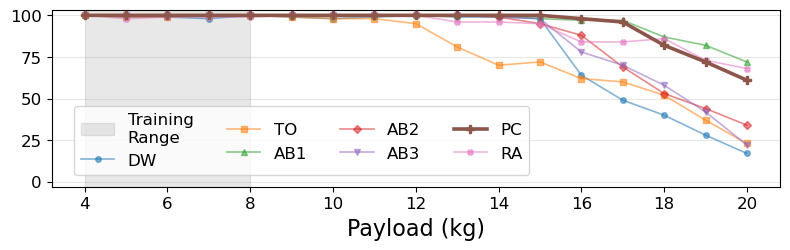

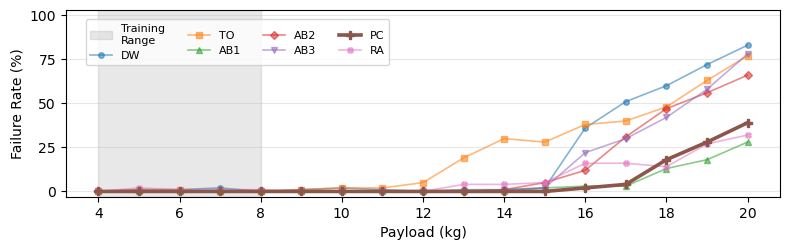

In [15]:
PLOT_TERRAIN = "plane" if "plane" in payload_summary["terrain"].unique() else None

payloads, success_rates = payload_curve_dict(payload_summary, "success_rate", terrain=PLOT_TERRAIN)
_, failure_rates = payload_curve_dict(payload_summary, "failure_rate", terrain=PLOT_TERRAIN)
approach_order =  list(success_rates.keys()) if APPROACH_ORDER is None else APPROACH_ORDER

fig, ax = plot_payload_success_curves(payloads, success_rates, approach_order, highlight=HIGHLIGHT_APPROACH, shade_until=8.0, shade_label="Training\nRange")
fig.savefig(RESULTS_DIR / "payload_success_curves.png", dpi=300, bbox_inches="tight")
plt.show()

if SAVE_AS_PDF:
    compactify_plot(fig, ax)
    save_paper_fig(fig, RESULTS_DIR / "payload_success_curves.pdf")

fig, ax = plot_payload_failure_curves(payloads, failure_rates, approach_order, highlight=HIGHLIGHT_APPROACH, shade_until=8.0, shade_label="Training\nRange")
fig.savefig(RESULTS_DIR / "payload_failure_curves.png", dpi=300, bbox_inches="tight")
plt.show()

if SAVE_AS_PDF:
    compactify_plot(fig, ax)
    save_paper_fig(fig, RESULTS_DIR / "payload_failure_curves.pdf")


## Maximum payload before success threshold


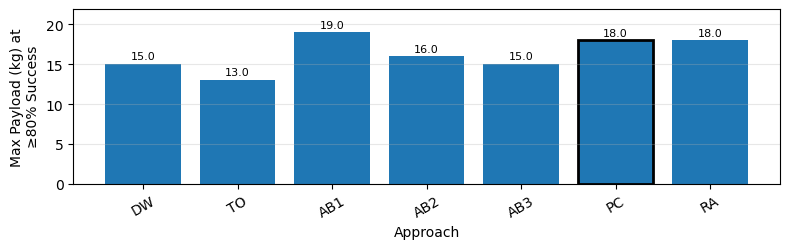

In [16]:
thresholds = compute_payload_threshold(payloads, success_rates, threshold=SUCCESS_THRESHOLD)
threshold_table = pd.DataFrame({
    "approach": list(thresholds.keys()),
    "max_payload_at_threshold": list(thresholds.values()),
    "success_threshold": SUCCESS_THRESHOLD,
})
threshold_table.to_csv(RESULTS_DIR / "payload_success_thresholds.csv", index=False)
fig, ax = plot_payload_thresholds(thresholds, threshold=SUCCESS_THRESHOLD, highlight=HIGHLIGHT_APPROACH, approach_order=approach_order)
fig.savefig(RESULTS_DIR / "payload_success_thresholds.png", dpi=300, bbox_inches="tight")
plt.show()

if SAVE_AS_PDF:
    compactify_plot(fig, ax)
    save_paper_fig(fig, RESULTS_DIR / "payload_success_thresholds.pdf")

## DoF and height tracking vs. payload


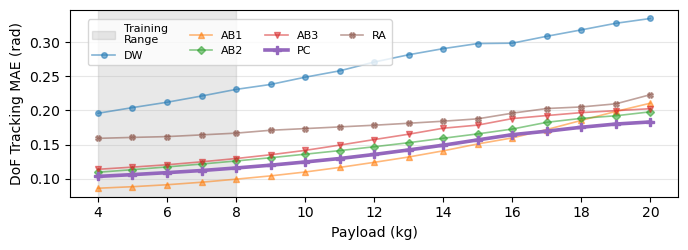

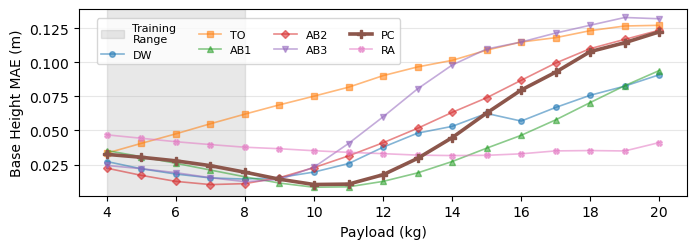

In [17]:
if "dof_tracking_mae" in payload_summary.columns:
    fig, ax = plot_metric_vs_payload(payload_summary, "dof_tracking_mae", terrain=PLOT_TERRAIN, ylabel="DoF Tracking MAE (rad)", highlight=HIGHLIGHT_APPROACH, 
                                     approach_order=approach_order, shade_until=8.0, shade_label="Training\nRange",
                                     exclude_approaches=["TO"])
    
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        ncol=4,  # 7 entries -> 2 rows
        frameon=True,
        fontsize=8,
        )
    
    fig.savefig(RESULTS_DIR / "payload_dof_tracking_mae.png", dpi=300, bbox_inches="tight")
    plt.show()

    if SAVE_AS_PDF:
        compactify_plot(fig, ax)
        save_paper_fig(fig, RESULTS_DIR / "payload_dof_tracking_mae.pdf")

else:
    print("dof_tracking_mae is not available.")

if "height_mae" in payload_summary.columns:
    fig, ax = plot_metric_vs_payload(payload_summary, "height_mae", terrain=PLOT_TERRAIN, ylabel="Base Height MAE (m)", highlight=HIGHLIGHT_APPROACH, approach_order=approach_order, shade_until=8.0, shade_label="Training\nRange")
    
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        ncol=4,  # 7 entries -> 2 rows
        frameon=True,
        fontsize=8,
        )
    
    fig.savefig(RESULTS_DIR / "payload_height_mae.png", dpi=300, bbox_inches="tight")
    plt.show()

    if SAVE_AS_PDF:
        compactify_plot(fig, ax)
        save_paper_fig(fig, RESULTS_DIR / "payload_height_mae.pdf")

else:
    print("height_mae is not available.")


## Optional: plot any metric from the existing analysis


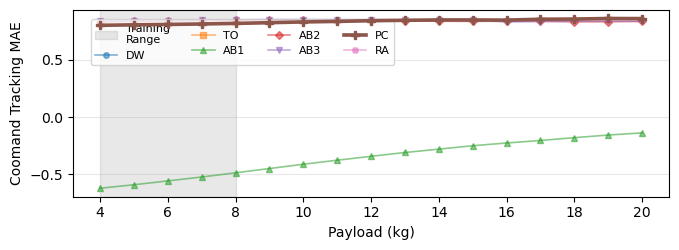

['approach', 'terrain', 'payload_mass', 'num_episodes', 'success_rate', 'failure_rate', 'timeout_rate', 'episode_length_mean', 'dof_tracking_mae', 'height_mae', 'lin_cmd_mae', 'ang_cmd_mae', 'total_cmd_mae', 'total_cmd_rmse', 'projected_gravity_rp_norm_mean', 'z_vel_mae', 'ang_vel_rp_norm_mean', 'joint_power_norm_mean', 'grf_norm_mean', 'ff_tau_norm_mean', 'pd_tau_norm_mean', 'pd_to_ff_power_ratio', 'power_alignment_mean', 'fraction_antagonistic_energy', 'internal_power_cancellation']


In [18]:
METRIC_TO_PLOT = "power_alignment_mean"
if METRIC_TO_PLOT in payload_summary.columns:
    fig, ax = plot_metric_vs_payload(payload_summary, METRIC_TO_PLOT, terrain=PLOT_TERRAIN, ylabel="Coomand Tracking MAE", highlight=HIGHLIGHT_APPROACH, approach_order=approach_order, shade_until=8.0, shade_label="Training\nRange")
    
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        ncol=4,  # 7 entries -> 2 rows
        frameon=True,
        fontsize=8,
        )
    
    fig.savefig(RESULTS_DIR / f"payload_{METRIC_TO_PLOT}.png", dpi=300, bbox_inches="tight")
    plt.show()

    if SAVE_AS_PDF:
        compactify_plot(fig, ax)
        save_paper_fig(fig, RESULTS_DIR / f"payload_{METRIC_TO_PLOT}.pdf")

else:
    print(f"{METRIC_TO_PLOT!r} is not available.")
    print(payload_summary.columns.tolist())
print(payload_summary.columns.tolist())

## Export final tables


In [19]:
per_file_metrics.to_csv(RESULTS_DIR / "per_file_metrics.csv", index=False)
per_episode_results.to_csv(RESULTS_DIR / "per_episode_results.csv", index=False)
payload_summary.to_csv(RESULTS_DIR / "payload_summary.csv", index=False)
threshold_table.to_csv(RESULTS_DIR / "payload_success_thresholds.csv", index=False)

print("Final outputs written to:")
for name in [
    "per_file_metrics.csv", "per_episode_results.csv", "payload_summary.csv", "payload_success_thresholds.csv",
    "payload_success_curves.png", "payload_failure_curves.png", "payload_success_thresholds.png",
    "payload_dof_tracking_mae.png", "payload_height_mae.png",
]:
    print(RESULTS_DIR / name)


Final outputs written to:
exp_data_corl_10/payload_max/payload_analysis_results/per_file_metrics.csv
exp_data_corl_10/payload_max/payload_analysis_results/per_episode_results.csv
exp_data_corl_10/payload_max/payload_analysis_results/payload_summary.csv
exp_data_corl_10/payload_max/payload_analysis_results/payload_success_thresholds.csv
exp_data_corl_10/payload_max/payload_analysis_results/payload_success_curves.png
exp_data_corl_10/payload_max/payload_analysis_results/payload_failure_curves.png
exp_data_corl_10/payload_max/payload_analysis_results/payload_success_thresholds.png
exp_data_corl_10/payload_max/payload_analysis_results/payload_dof_tracking_mae.png
exp_data_corl_10/payload_max/payload_analysis_results/payload_height_mae.png
